# Segmentation de cellule

Dans ce TP, nous allons reprendre le TP sur la segmentation des cellules. Il s'agit d'expliquer sous forme d'une présentation :
- le dataset sur lequel vous avez travaillé
- le modèle choisi
- l'apprentissage du modèle sur vos données
- les performances de votre modèle sur des données qu'il n'a jamais vu: pour quelles images le modèle est performant ou pas.

# Installation des librairies

Il s'agit de librairies qui seront utilisées pour manipuler les images et le réseau de neurone. Il contient une fonction pour simplement rendre quelques images visibles à titre d'illustration.

In [ ]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import imageio
import matplotlib.pyplot as plt

from tqdm import tqdm
from itertools import chain
from skimage.io import imread, imshow, imread_collection, concatenate_images
from skimage.transform import resize
from skimage.morphology import label

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.layers import BatchNormalization, Activation, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
import cv2
import tensorflow as tf
import matplotlib.patches as mpatches

!pip install livelossplot

def show_image(ix,x_train,y_train):
  fig = plt.figure(figsize=(10, 10))
  plt.subplot(121)
  plt.imshow(x_train[ix,:,:])
  plt.subplot(122)
  plt.imshow(y_train[ix, :, :, 0],cmap='gray')
  plt.axis('off')
  plt.show()

def get_data(path, train=True):
    """
    Loads and preprocesses image data.

    Args:
        path (str): Path to the directory containing the image data.
        train (bool, optional): Flag indicating if the data is for training.
                                 Defaults to True.

    Returns:
        tuple or ndarray: If train is True, returns a tuple containing the
                          image data (X) and corresponding masks (Y).
                          If train is False, returns only the image data (X).
    """
    # Get the list of image IDs
    ids = next(os.walk(path))[1]

    # Initialize arrays to store image data and masks
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)

    # Initialize masks array only if train is True
    if train:
        Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype=bool)

    print('Getting and resizing images ... ')
    sys.stdout.flush()

    # Iterate through each image ID
    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        path_new = os.path.join(path,id_)

        # Read and resize the image
        img = imread(path_new + '/images/' + id_ + '.png')[:,:,:IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img

        # Read and process masks only if train is True
        if train:
            mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=bool)
            for mask_file in next(os.walk(path_new + '/masks/'))[2]:
                mask_ = imread(path_new + '/masks/' + mask_file)
                mask_ = np.expand_dims(resize(mask_, (IMG_HEIGHT, IMG_WIDTH), mode='constant',
                                              preserve_range=True), axis=-1)
                mask = np.maximum(mask, mask_)
            Y[n] = mask

    # Return image data and masks (if train is True) or only image data
    if train:
        return X, Y
    else:
        return X

def dice_coefficient(y_true, y_pred):
    eps = 1e-6
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    #Casting to float32 to resolve the type error
    y_true_f = tf.cast(y_true_f, dtype=tf.float32)
    y_pred_f = tf.cast(y_pred_f, dtype=tf.float32)
    intersection = K.sum(y_true_f * y_pred_f)
    # Ensure denominator is not zero by adding a small value(1e-6) to avoid division by zero errors
    result = (2. * intersection + 1e-6) / (K.sum(y_true_f * y_true_f) + K.sum(y_pred_f * y_pred_f) + 1e-6)
    return result

def image_confusion(GT,predict):

  # Conversion en booléen directement
  GT_new = GT.astype('uint8')

  # Création de l'image de sortie avec NumPy
  IMAGE_OUTPUT = np.zeros((GT.shape[0],GT.shape[1], 3), dtype="uint8")

  # Conditions pour chaque cas
  TP = (predict == 1) & (GT_new == 1)  # True Positive (Blanc)
  FP = (predict == 1) & (GT_new == 0)  # False Positive (Rouge)
  FN = (predict == 0) & (GT_new == 1)  # False Negative (Vert)
  TN = (predict == 0) & (GT_new == 0)  # True Negative (Noir)

  # Assignation des couleurs
  IMAGE_OUTPUT[TP] = [255, 255, 255]  # Blanc
  IMAGE_OUTPUT[FP] = [255, 0, 0]      # Rouge
  IMAGE_OUTPUT[FN] = [0, 255, 0]      # Vert
  IMAGE_OUTPUT[TN] = [0, 0, 0]        # Noir
  IMAGE_OUTPUT = np.array(IMAGE_OUTPUT)
  return IMAGE_OUTPUT

def pred_vis(x_data,y_data,preds_data,preds_data_t):
  ix = random.randint(0, len(x_data))

  gt = y_data[ix, :, :,0]
  pred = preds_data_t[ix, :, :,0]
  IMAGE_OUTPUT = image_confusion(gt,pred)
  dice = dice_coefficient(gt, pred)
  # show the plot
  fig = plt.figure(figsize=(20, 20))
  plt.subplot(151)
  plt.imshow(x_data[ix,:,:])
  plt.title("input image")
  plt.axis('off')
  plt.subplot(152)
  plt.imshow(np.squeeze(y_data[ix, :, :, 0]),cmap='gray')
  plt.title("ground truth")
  plt.axis('off')
  plt.subplot(153)
  plt.imshow(np.squeeze(preds_data[ix, :, :]))
  plt.title("Probability map of the predicted mask")
  plt.axis('off')
  plt.subplot(154)
  plt.imshow(np.squeeze(preds_data_t[ix, :, :, 0]),cmap='gray')
  plt.title("Probability map thresholded\n Dice "+str(np.around(dice,3)))
  plt.axis('off')
  plt.subplot(155)
  plt.imshow(IMAGE_OUTPUT)
  legend_patches = [
        mpatches.Patch(color='white', label='True Positive (Blanc)'),
        mpatches.Patch(color='red', label='False Positive (Rouge)'),
        mpatches.Patch(color='green', label='False Negative (Vert)'),
        mpatches.Patch(color='black', label='True Negative (Noir)'),
    ]
  plt.legend(handles=legend_patches, loc='upper left',bbox_to_anchor=(1.1,.9), fontsize=10, frameon=True)
  plt.title("Image de confusion")
  plt.axis('off')
  plt.show()

def vis_prob_maps(x_data,y_data,preds_test):
  ix = random.randint(0, len(x_data))
  gt = Y_test[ix, :,:,0]
  rgb = X_test[ix,:,:]
  map_pred = preds_test[ix,...]

  # show the plot
  fig = plt.figure(figsize=(20, 20))
  plt.subplot(151)
  plt.imshow(rgb)
  plt.title("input image")
  plt.axis('off')
  plt.subplot(152)
  plt.imshow(np.squeeze(gt),cmap='gray')
  plt.title("ground truth")
  plt.axis('off')
  plt.subplot(153)
  plt.imshow(np.squeeze(map_pred))
  plt.title("Probability map")
  plt.axis('off')
  plt.show()

def thr_optimize(preds_data):
  from sklearn.metrics import f1_score

  # compute F1-score for a set of thresholds from (0.1 to 0.9 with a step of 0.1)
  prob_thresh = [i*10**-1 for i in range(1,10)]
  perf=[] # define an empty array to store the computed F1-score for each threshold
  perf_ALL=[]
  for r in tqdm(prob_thresh): # all th thrshold values
      preds_bin = ((preds_data> r) + 0 )
      preds_bin1=preds_bin[:,:,:,0]
      GTALL=y_val[:,:,:,0]
      for ii in range(len(GTALL)): # all validation images
          predmask=preds_bin1[ii,:,:]
          GT=GTALL[ii,:,:]
          l = GT.flatten()
          p= predmask.flatten()
          perf.append(f1_score(l, p)) # re invert the maps: cells: 1, back :0
      perf_ALL.append(np.mean(perf))
      perf=[]

  plt.figure(figsize=(10,10))
  plt.plot(prob_thresh, perf_ALL,'ro-')
  plt.ylim(top=1)
  plt.xticks(prob_thresh)
  plt.tick_params(axis='x', labelsize=12)
  plt.tick_params(axis='y', labelsize=12)
  plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
  plt.xlabel('predicted probability map threshold',fontsize=12)
  plt.ylabel('F1-score', fontsize=12)
  None;
  max_f1 = max(perf_ALL)  # Find the maximum y value
  op_thr = prob_thresh[np.array(perf_ALL).argmax()]  # Find the x value corresponding to the maximum y value
  plt.title('Best threshold is: '+str(op_thr)+' for F1-score='+str(np.around(max_f1,3)),fontsize=14)
  print("Optimizing threshold for predicted probability maps")
  return op_thr

#Each block of u-net architecture consist of two Convolution layers
# These two layers are written in a function to make our code clean
def conv2d_block(input_tensor, n_filters,kernel_size=3):
    x = Conv2D(filters=n_filters,kernel_size=(kernel_size, kernel_size),activation='relu', padding="same")(input_tensor)
    x = Conv2D(filters=n_filters,kernel_size=(kernel_size, kernel_size),activation='relu', padding="same")(x)
    return x

# The u-net architecture consists of contracting and expansive paths which
# shrink and expands the inout image respectivly.
# Output image have the same size of input image
def get_unet(input_img, n_filters):
    # contracting path
    c1 = conv2d_block(input_img, n_filters=n_filters*4, kernel_size=3) #The first block of U-net
    p1 = MaxPooling2D((2, 2)) (c1)

    c2 = conv2d_block(p1, n_filters=n_filters*8, kernel_size=3)
    p2 = MaxPooling2D((2, 2)) (c2)

    c3 = conv2d_block(p2, n_filters=n_filters*16, kernel_size=3)
    p3 = MaxPooling2D((2, 2)) (c3)

    c4 = conv2d_block(p3, n_filters=n_filters*32, kernel_size=3)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

    c5 = conv2d_block(p4, n_filters=n_filters*64, kernel_size=3) # last layer on encoding path

    # expansive path
    u6 = Conv2DTranspose(n_filters*32, (3, 3), strides=(2, 2), padding='same') (c5) #upsampling included
    u6 = concatenate([u6, c4])
    c6 = conv2d_block(u6, n_filters=n_filters*32, kernel_size=3)

    u7 = Conv2DTranspose(n_filters*16, (3, 3), strides=(2, 2), padding='same') (c6)
    u7 = concatenate([u7, c3])
    c7 = conv2d_block(u7, n_filters=n_filters*16, kernel_size=3)

    u8 = Conv2DTranspose(n_filters*8, (3, 3), strides=(2, 2), padding='same') (c7)
    u8 = concatenate([u8, c2])
    c8 = conv2d_block(u8, n_filters=n_filters*8, kernel_size=3)

    u9 = Conv2DTranspose(n_filters*4, (3, 3), strides=(2, 2), padding='same') (c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = conv2d_block(u9, n_filters=n_filters*4, kernel_size=3)

    outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)
    model = Model(inputs=[input_img], outputs=[outputs])
    return model

from google.colab import drive
!pip install -q scikit-learn
from sklearn.model_selection import train_test_split
# Set some parameters
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3

# Importation des données

In [ ]:
root = '/content/gdrive/'
drive.mount(root)

Mounted at /content/gdrive/


Télécharger le [base de donnée](https://drive.google.com/file/d/1ZNoqmFJVK-1n9CtgfNI1B2UrKs_5aZRA/view?usp=drive_link) puis déposer le dans un dossier. Retrouvez le chemin **data.zip** puis copier-coller en-dessous :

In [ ]:
# !wget https://drive.google.com/file/d/1ZNoqmFJVK-1n9CtgfNI1B2UrKs_5aZRA/view?usp=sharing -O data.zip
!unzip -q /content/gdrive/MyDrive/M2BEE/data.zip # <--- ici

Dans nos données, on a:

- Images couleurs: des images de cellules sanguines

- Masque vérité terrain: des masques où des humains ont dessinés à la main la position des cellules dans l'image

**L'objectif de ce TP est que ça soit une intelligence artificielle qui dessine la position des cellules dans l'image**

# Constituer une base de données train et validation

Dans cette section, on crée une base train, validation, test. Nous montrons la quantité d'images dans chaque base.

In [ ]:
TRAIN_PATH = 'data/nuclei_train_data/'
TEST_PATH = 'data/nuclei_val_data/'

warnings.filterwarnings('ignore', category=UserWarning, module='skimage')

X, Y = get_data(TRAIN_PATH, train=True)
X_test,Y_test = get_data(TEST_PATH, train=True)
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42) #text_size=0.3 (à moi, 0.2)

print('Train data shape:', x_train.shape)
print('Train label shape:', y_train.shape)
print('Val data shape:', x_val.shape)
print('Val label shape:', y_val.shape)
print('Test data shape:', X_test.shape)
print('Test label shape:', Y_test.shape)

Getting and resizing images ... 


100%|██████████| 536/536 [03:48<00:00,  2.35it/s]

Getting and resizing images ... 



100%|██████████| 134/134 [00:58<00:00,  2.29it/s]

Train data shape: (428, 256, 256, 3)
Train label shape: (428, 256, 256, 1)
Val data shape: (108, 256, 256, 3)
Val label shape: (108, 256, 256, 1)
Test data shape: (134, 256, 256, 3)
Test label shape: (134, 256, 256, 1)


Ci-dessous, un échantillon d'images dans la base train.

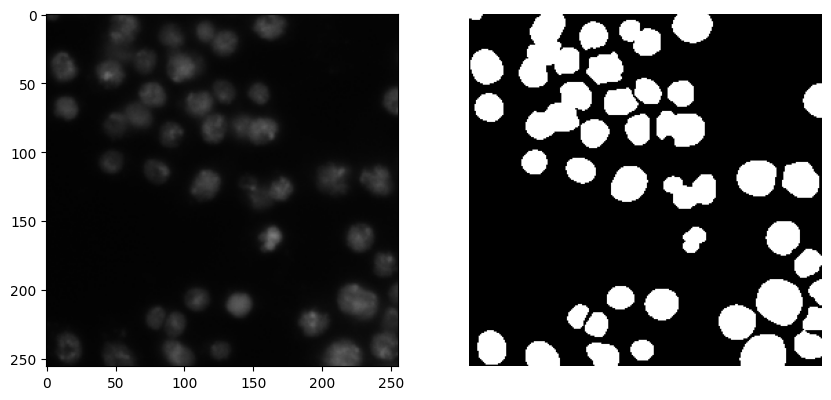

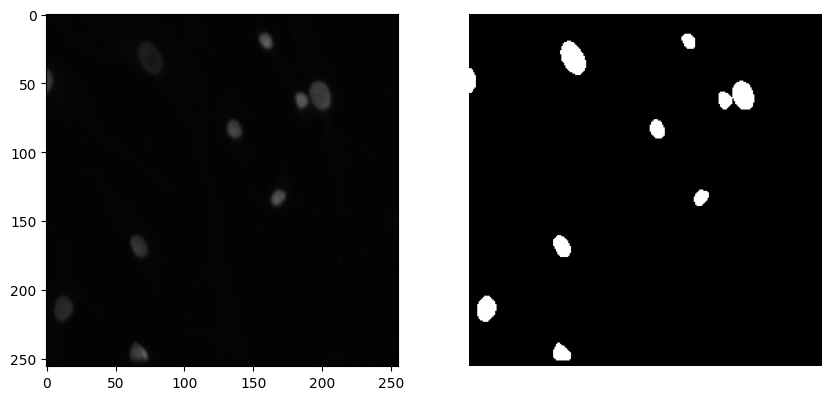

In [ ]:
show_image(5,x_train,y_train)
show_image(75,x_train,y_train)

# Entrainement du modèle de Segmentation : UNet

Dans cette section, on va faire un apprentissage du modèle UNet sur nos données. Pour l'apprentissage, il suffit de régler le **learning_rate** et le **batch_size**. Vous pouvez commencer un apprentissage avec les valeurs par défaut.

Quelques hyperparamètres à ne pas changer:

**early-stopping** a été activé. Rappelons qu'il permet deux choses:
- Sauvegarder le meilleur modèle
- Eviter l'apparition du surapprentissage. Il est alors impossible que le meilleur modèle sauvegardé a surappris sur nos données.

calcul de l'erreur de prédiction: binary_crossentropy qui l'erreur entre les pixels prédits et vérité terrain

calul de la performance de segmentation: dice_coefficient qui mesure le chevauchement entre un masque vérité terrain et prédit

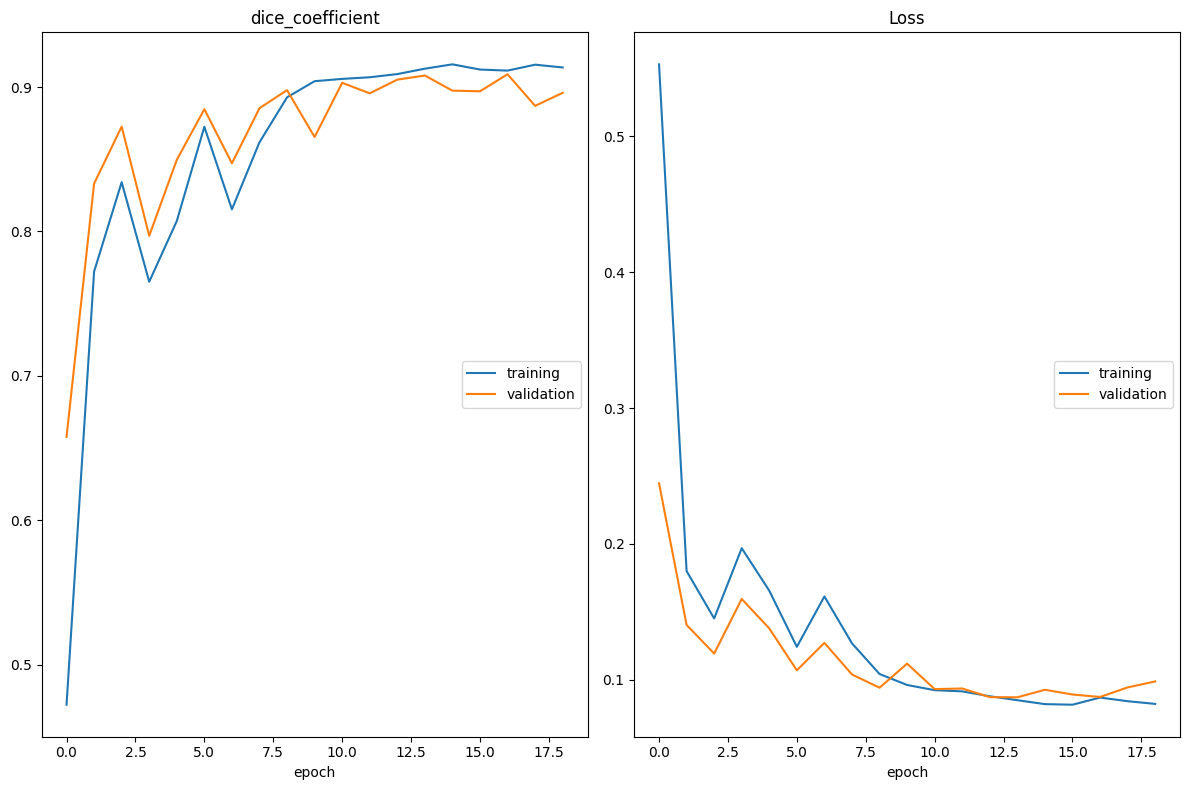

dice_coefficient
	training         	 (min:    0.472, max:    0.916, cur:    0.914)
	validation       	 (min:    0.658, max:    0.909, cur:    0.896)
Loss
	training         	 (min:    0.082, max:    0.553, cur:    0.082)
	validation       	 (min:    0.087, max:    0.245, cur:    0.099)

Epoch 19: val_loss did not improve from 0.08712
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - dice_coefficient: 0.9139 - loss: 0.0769 - val_dice_coefficient: 0.8960 - val_loss: 0.0988
Epoch 19: early stopping


In [ ]:
learning_rate = 0.0007 #@param {type:"number"}
batch_size = 4 #@param {type:"number"}

# Creating and Compiling the model
input_img = Input((x_train.shape[1], x_train.shape[2], 3), name='img')
model = get_unet(input_img, n_filters=3)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss="binary_crossentropy", metrics=[dice_coefficient])
model.summary()

checkpoint_filepath = os.path.join('/content/unet_best.keras')

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, verbose=1, mode='auto') #Stop training when a monitored metric has stopped improving.

Model_check = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_filepath, monitor='val_loss', verbose=1, save_best_only=True,
    save_weights_only=False, mode='auto') #Callback to save the Keras model or model weights at some frequency.

# Fiting the model
from livelossplot import PlotLossesKeras
plotlossesdeeper = PlotLossesKeras()
results = model.fit(x_train, y_train,
                    validation_data=(x_val,y_val),
                    batch_size=batch_size, epochs=500,
                    verbose=1,
                    callbacks=[plotlossesdeeper,early_stop,Model_check])

# Post-traitement du modèle

Rappelons qu'à la fin du modèle U-Net, on obtient une carte de probabilité : une image où chaque pixel est une probabilité de 0 à 1 pour que ce pixel soit un pixel "cellule".

Comme on veut obtenir un masque c'est à dire une image avec 1 pour "cellule" et 0 pour "fond image", on va appliquer un seuillage dans la carte de probabilité.

On va dire que toutes les probabilités au-dessus du seuil est une cellule, toutes les probabiltiés en-dessus du seuil est un fond image.

La cellule ci-dessous vous montre un exemple de seuil qui divise la carte de probabilité en deux.

INFORMATION SUR LA VISUALISATION:

- input image : Image couleur en entrée

- ground truth : Vérité terrain

- Probability map of the predicted mask : Carte probabilité

- Probability map thresholded : Masque prédit

- Image confusion : Image qui montre vrai positif, faux positif, vrai négatif et faux négatif

Définitions:

- Vrai positif: Pixel "cellule" bien prédit par le modèle

- Vrai négatif: Pixel "fond image" bien prédit par le modèle

- Faux positif: Pixel "cellule" prédit qui n'apparait pas dans la vérité terrain. Modèle a prédit le pixel comme une "cellule" à tort.

- Faux négatif: Pixel "fond image" prédit qui est en réalité un pixel "cellule"

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


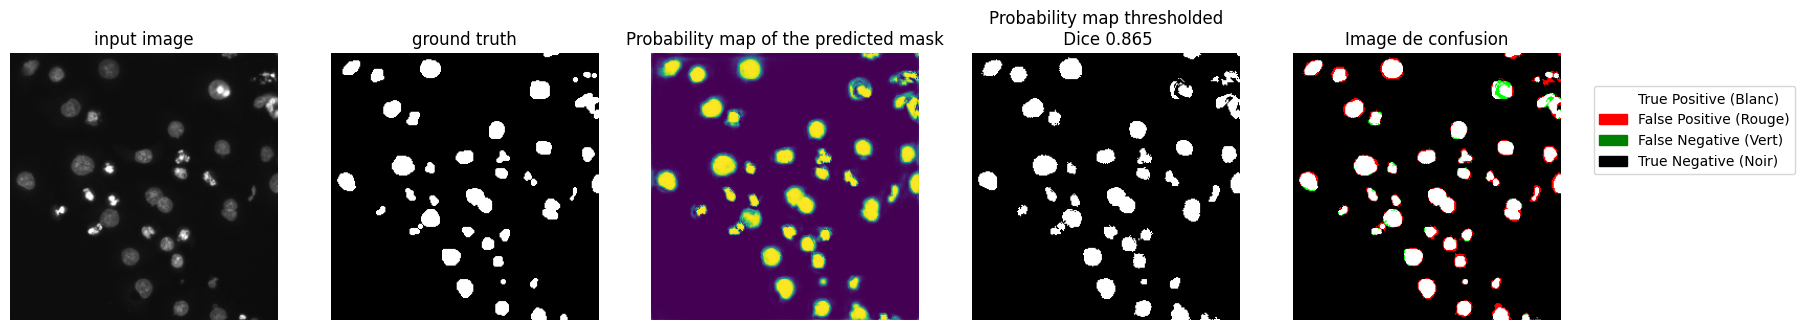

In [ ]:
op_thr = 0.5 #@param {type:"number"}
model_best = tf.keras.models.load_model(checkpoint_filepath,custom_objects={'dice_coefficient': dice_coefficient})
preds_val = model_best.predict(x_val, verbose=1)
preds_val_t = (preds_val > op_thr).astype(np.uint8) # we apply a threshold on predicted mask (probability mask) to convert it to a binary mask.
pred_vis(x_val,y_val,preds_val,preds_val_t)

Ici, on a un algorithme qui trouve le meilleur seuil. Il cherche parmi les seuils 0,0.1,...,0.9,1 qui permet d'obtenir un masque prédit et un masque vérité terrain qui se chevauchent parfaitement. Cette recherche est appliqué sur les données validation car les données validation sont là pour calculer l'erreur et régler les hyperparamètres (dont le seuil).

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step


100%|██████████| 9/9 [00:10<00:00,  1.13s/it]


Optimizing threshold for predicted probability maps


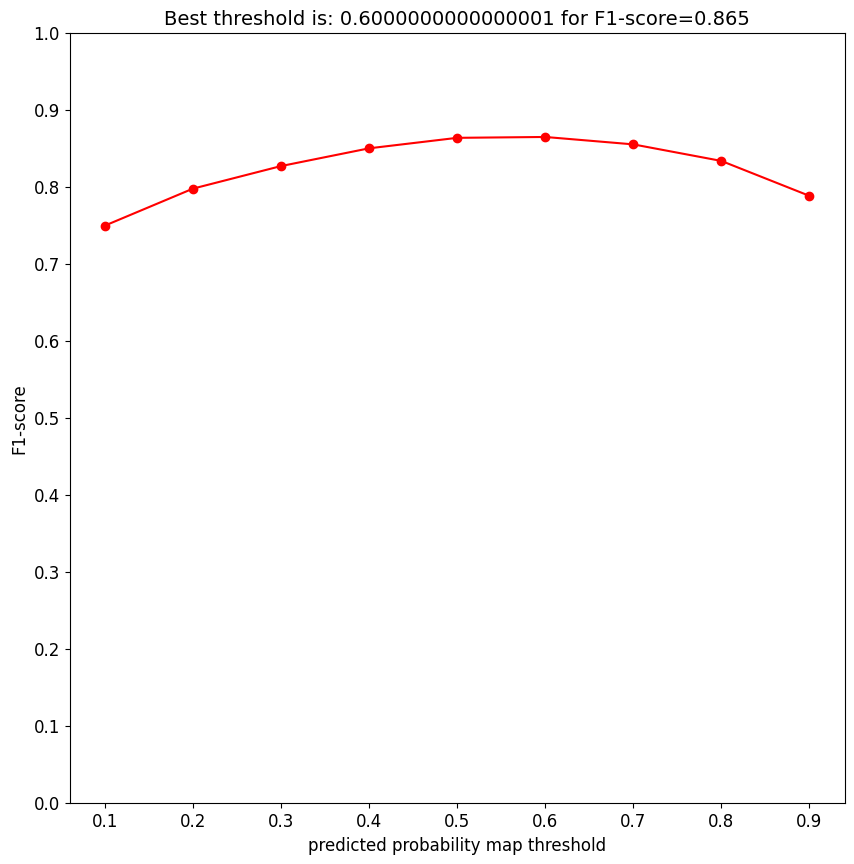

In [ ]:
model_best = tf.keras.models.load_model(checkpoint_filepath,custom_objects={'dice_coefficient': dice_coefficient})
preds_val = model_best.predict(x_val, verbose=1)
op_thr = thr_optimize(preds_val)
preds_val_t = (preds_val > op_thr).astype(np.uint8) # we apply a threshold on predicted mask (probability mask) to convert it to a binary mask.

Application du meilleur seuil sur les données de validation

Dice coefficient: 0.889


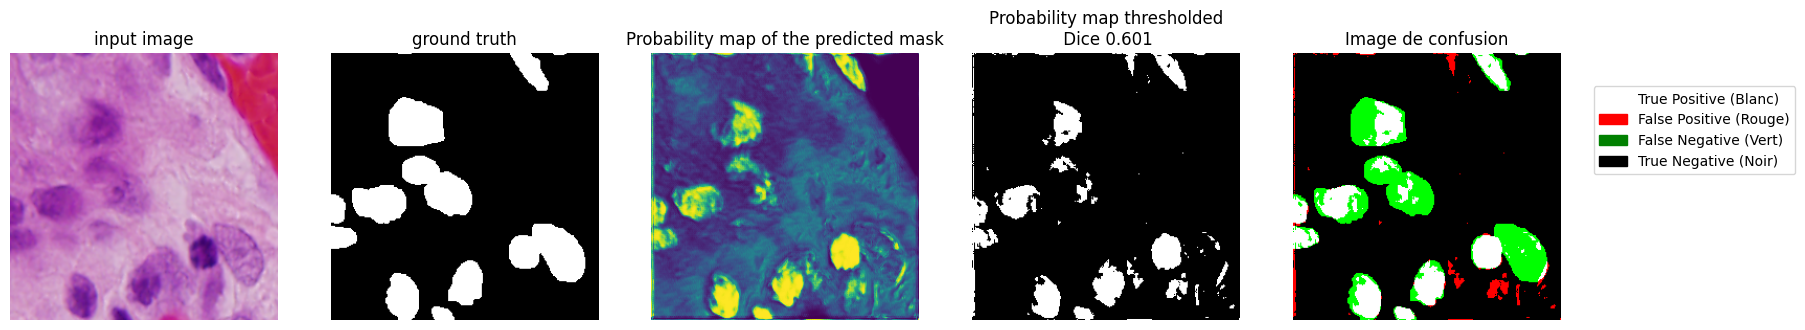

In [ ]:
dice = K.get_value(dice_coefficient(y_val, preds_val_t))
print("Dice coefficient:", np.around(dice,3))
pred_vis(x_val,y_val,preds_val,preds_val_t)

Application du meilleur seuil sur les données de test

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Dice coefficient: 0.899


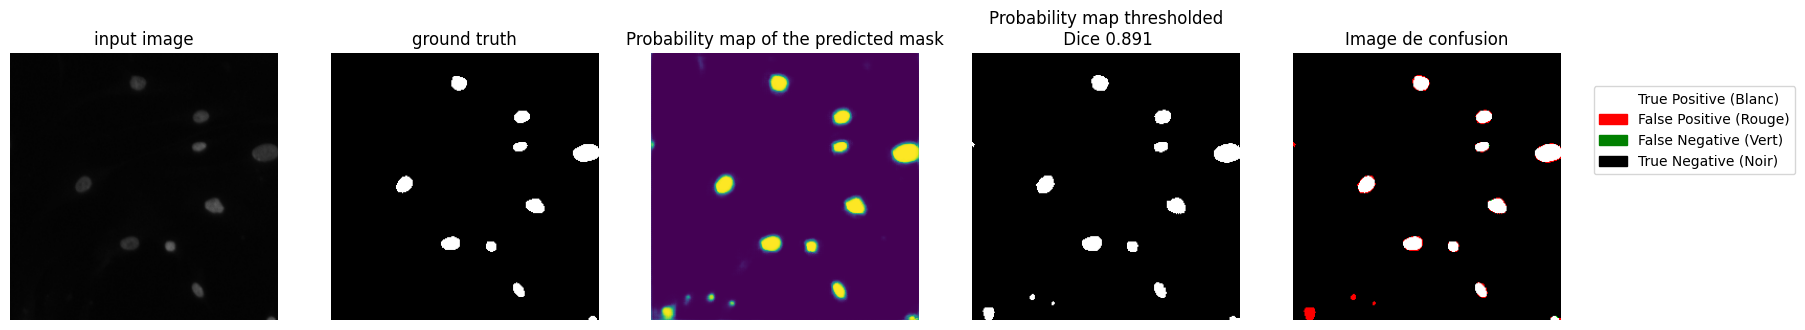

In [ ]:
preds_test = model_best.predict(X_test, verbose=1)
preds_test_t = (preds_test > op_thr).astype(np.uint8)
dice = K.get_value(dice_coefficient(Y_test, preds_test_t))
print("Dice coefficient:", np.around(dice,3))
pred_vis(X_test,Y_test,preds_test,preds_test_t)

### Analyse des résultats

- Cas segmentation parfaite : quels éléments permettent de bien segmenter les cellules ? Bonne visibilité de la cellule comparé au fond image ? etc ?
- Cas segmentation pas parfaite : Dans quel endroit dans les images la segmentation est difficile ?